---
# DNN : `MNIST` (avec `Keras`)
---

## Packages

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras import callbacks, layers, models
from keras.datasets import mnist

---
## 1. Données
---

### 1.1. Importation

In [2]:
test_portion  = 1/5

(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=test_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

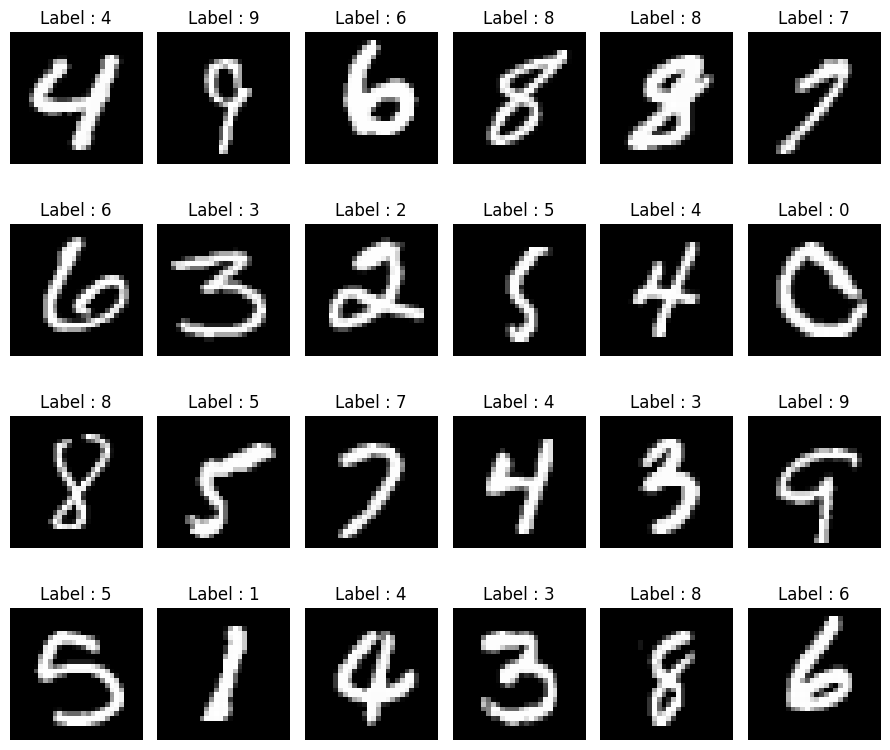

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [4]:
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. DNN
---

### 2.1. Architecture

In [5]:
dim_inputs  = (28, 28, 1)
dim_outputs = 10

n_units_hl1 = 100
n_units_hl2 = 100

dropout_hl1 = 0.2
dropout_hl2 = 0.2

model = models.Sequential(name='DNN')

model.add(layers.Input(shape=dim_inputs, name='Inputs'))

model.add(layers.Flatten(name='Flatten'))

model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))
model.add(layers.Dropout(rate=dropout_hl1, name='Dropout_Hidden_layer_1'))

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))
model.add(layers.Dropout(rate=dropout_hl2, name='Dropout_Hidden_layer_2'))

model.add(layers.Dense(units=dim_outputs, activation='softmax', name='Output_layer'))

model.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_layer_1 (Dense)               │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_Hidden_layer_1 (Dropout)     │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_layer_2 (Dense)               │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_Hidden_layer_2 (Dropout)     │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_layer (Dense)                 │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [ ]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [7]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6606 - loss: 1.0922 - val_accuracy: 0.9226 - val_loss: 0.2613
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9144 - loss: 0.2874 - val_accuracy: 0.9418 - val_loss: 0.1936
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9363 - loss: 0.2220 - val_accuracy: 0.9506 - val_loss: 0.1601
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9483 - loss: 0.1710 - val_accuracy: 0.9572 - val_loss: 0.1402
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9553 - loss: 0.1514 - val_accuracy: 0.9623 - val_loss: 0.1260
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9600 - loss: 0.1317 - val_accuracy: 0.9647 - val_loss: 0.1154
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9647 - loss: 0.1202 - val_accuracy: 0.9692 - val_loss: 0.1070
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9669 - loss: 0.1115 - val_accuracy: 0.

### 2.4. Prévisions

In [8]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[1.1584086e-08, 5.5255519e-08, 2.9417356e-06, 2.1078073e-05,
        1.8078208e-10, 1.3274096e-07, 2.9308517e-11, 9.9996984e-01,
        2.0008367e-08, 5.9410413e-06],
       [3.1539187e-09, 1.5575733e-05, 9.9998009e-01, 4.3022856e-06,
        1.4526908e-12, 8.0771773e-10, 3.2346044e-09, 5.4948539e-09,
        1.1251264e-09, 4.0787381e-15],
       [8.2931621e-08, 9.9985957e-01, 5.2596893e-06, 3.5806172e-06,
        1.2945430e-05, 2.2927381e-06, 1.4438890e-05, 6.0638351e-05,
        4.0698669e-05, 4.5063797e-07],
       [9.9965119e-01, 8.9181569e-08, 2.6921593e-05, 1.0891777e-07,
        1.9978403e-07, 7.3624328e-06, 2.8977660e-04, 1.8583260e-05,
        4.6356710e-08, 5.5469345e-06],
       [9.3778226e-07, 1.1117963e-08, 1.7870589e-06, 2.5642990e-09,
        9.9987149e-01, 1.7047000e-08, 1.8379357e-07, 7.8957246e-06,
        6.1419025e-09, 1.1768607e-04]], dtype=float32)

In [9]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [10]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.0822
Exactitude test : 0.9762
